In [1]:
import pandas as pd
import os

# Path input katalog USGS
input_path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/input/query_usgs_indonesia_katalog_raw.csv"

# Path output final
output_dir = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output"
output_file = os.path.join(output_dir, "usgs_events_indonesia.csv")

# Load data
df = pd.read_csv(input_path)

# Filter koordinat Indonesia
indo_coord = df[
    (df['latitude'] >= -11.0) &
    (df['latitude'] <= 7.5) &
    (df['longitude'] >= 94.0) &
    (df['longitude'] <= 141.0)
]

# Filter tambahan berdasarkan nama lokasi
indo_place = df[df['place'].str.contains("Indonesia", case=False, na=False)]

# Gabungkan dua filter
indo = pd.concat([indo_coord, indo_place]).drop_duplicates()

# Simpan hasil
indo.to_csv(output_file, index=False)

print("Total event Indonesia:", len(indo))
print("File disimpan ke:", output_file)


Total event Indonesia: 16967
File disimpan ke: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia.csv


In [4]:
# ============================================================
# FILTER EVENT USGS AGAR HANYA WILAYAH INDONESIA (AKURAT 100%)
# Dengan auto-download shapefile Natural Earth (URL terbaru)
# ============================================================

!pip install geopandas shapely requests --quiet

import geopandas as gpd
import pandas as pd
import requests, zipfile, io, os
from shapely.geometry import Point

# ------------------------------------------------------------
# 1. Download shapefile Natural Earth (jika belum ada)
# ------------------------------------------------------------
shp_dir = "ne_110m_admin_0_countries"

if not os.path.exists(shp_dir):
    print("Mengunduh shapefile Natural Earth...")
    
    # URL resmi terbaru Natural Earth (stabil)
    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall(shp_dir)
    
    print("Shapefile berhasil diunduh dan diekstrak.")
else:
    print("Shapefile sudah tersedia.")

# ------------------------------------------------------------
# 2. Load shapefile dunia
# ------------------------------------------------------------
world = gpd.read_file(f"{shp_dir}/ne_110m_admin_0_countries.shp")

# Ambil polygon Indonesia
indo_poly = world[world['ADMIN'] == 'Indonesia']

# ------------------------------------------------------------
# 3. Load katalog USGS mentah
# ------------------------------------------------------------
input_path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/input/query_usgs_indonesia_katalog_raw.csv"
df = pd.read_csv(input_path)

# ------------------------------------------------------------
# 4. Konversi event menjadi GeoDataFrame
# ------------------------------------------------------------
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

# ------------------------------------------------------------
# 5. Spatial filtering: hanya titik yang berada DI DALAM polygon Indonesia
# ------------------------------------------------------------
indo_events = gdf[gdf.within(indo_poly.unary_union)]

# ------------------------------------------------------------
# 6. Simpan hasil
# ------------------------------------------------------------
output_path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon.csv"
indo_events.to_csv(output_path, index=False)

print("====================================================")
print("Total event Indonesia:", len(indo_events))
print("File disimpan ke:")
print(output_path)
print("====================================================")


Mengunduh shapefile Natural Earth...
Shapefile berhasil diunduh dan diekstrak.
Total event Indonesia: 2232
File disimpan ke:
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon.csv


/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_34691/2952149676.py:58: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  indo_events = gdf[gdf.within(indo_poly.unary_union)]


In [5]:
# ============================================================
# FILTER EVENT USGS: INDONESIA + BUFFER 2°
# Akurat untuk wilayah seismik Indonesia (termasuk megathrust)
# ============================================================

!pip install geopandas shapely requests --quiet

import geopandas as gpd
import pandas as pd
import requests, zipfile, io, os
from shapely.geometry import Point

# ------------------------------------------------------------
# 1. Download shapefile Natural Earth (jika belum ada)
# ------------------------------------------------------------
shp_dir = "ne_110m_admin_0_countries"

if not os.path.exists(shp_dir):
    print("Mengunduh shapefile Natural Earth...")
    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall(shp_dir)
    print("Shapefile berhasil diunduh dan diekstrak.")
else:
    print("Shapefile sudah tersedia.")

# ------------------------------------------------------------
# 2. Load shapefile dunia
# ------------------------------------------------------------
world = gpd.read_file(f"{shp_dir}/ne_110m_admin_0_countries.shp")

# Ambil polygon Indonesia
indo_poly = world[world['ADMIN'] == 'Indonesia']

# Tambahkan buffer 2 derajat (untuk zona megathrust)
indo_buffer = indo_poly.to_crs("EPSG:4326").buffer(2)

# ------------------------------------------------------------
# 3. Load katalog USGS mentah
# ------------------------------------------------------------
input_path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/input/query_usgs_indonesia_katalog_raw.csv"
df = pd.read_csv(input_path)

# ------------------------------------------------------------
# 4. Konversi event menjadi GeoDataFrame
# ------------------------------------------------------------
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

# ------------------------------------------------------------
# 5. Spatial filtering: Indonesia + buffer 2°
# ------------------------------------------------------------
indo_events = gdf[gdf.within(indo_buffer.unary_union)]

# ------------------------------------------------------------
# 6. Simpan hasil
# ------------------------------------------------------------
output_path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv"
indo_events.to_csv(output_path, index=False)

print("====================================================")
print("Total event Indonesia + buffer 2°:", len(indo_events))
print("File disimpan ke:")
print(output_path)
print("====================================================")


Shapefile sudah tersedia.


/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_34691/2354291573.py:37: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  indo_buffer = indo_poly.to_crs("EPSG:4326").buffer(2)
/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_34691/2354291573.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  indo_events = gdf[gdf.within(indo_buffer.unary_union)]


Total event Indonesia + buffer 2°: 12722
File disimpan ke:
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv


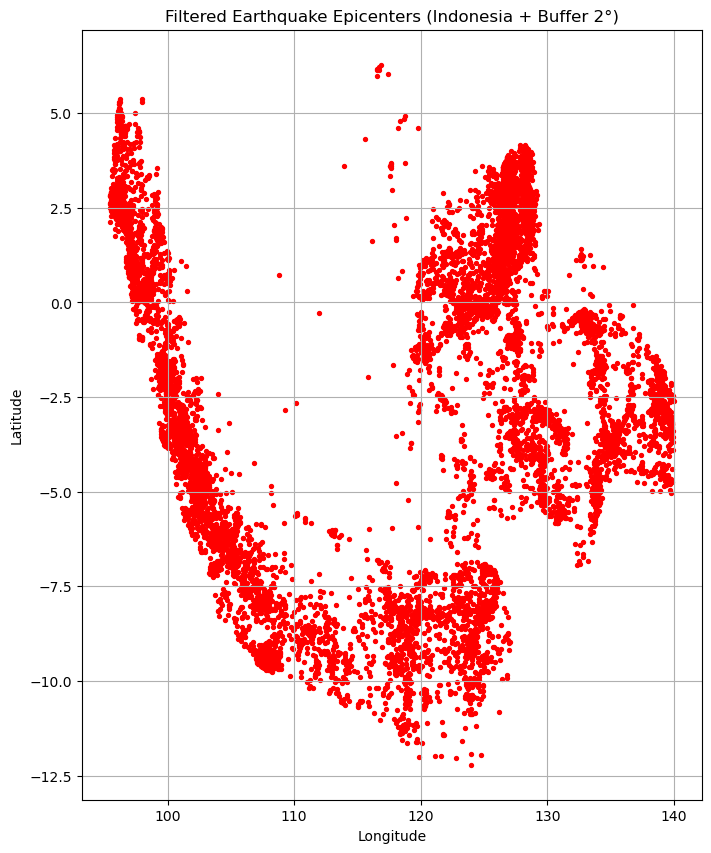

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv"

df = pd.read_csv(path)

plt.figure(figsize=(8, 10))
plt.scatter(df['longitude'], df['latitude'], s=8, c='red')
plt.title("Filtered Earthquake Epicenters (Indonesia + Buffer 2°)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


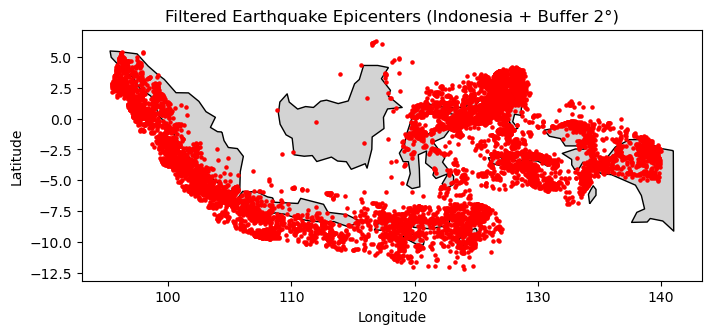

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load shapefile Indonesia
world = gpd.read_file("ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
indo = world[world['ADMIN'] == 'Indonesia']

# Load epicenter
path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv"
df = pd.read_csv(path)
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")

# Plot
fig, ax = plt.subplots(figsize=(8, 10))
indo.plot(ax=ax, color='lightgray', edgecolor='black')
gdf.plot(ax=ax, color='red', markersize=5)

plt.title("Filtered Earthquake Epicenters (Indonesia + Buffer 2°)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


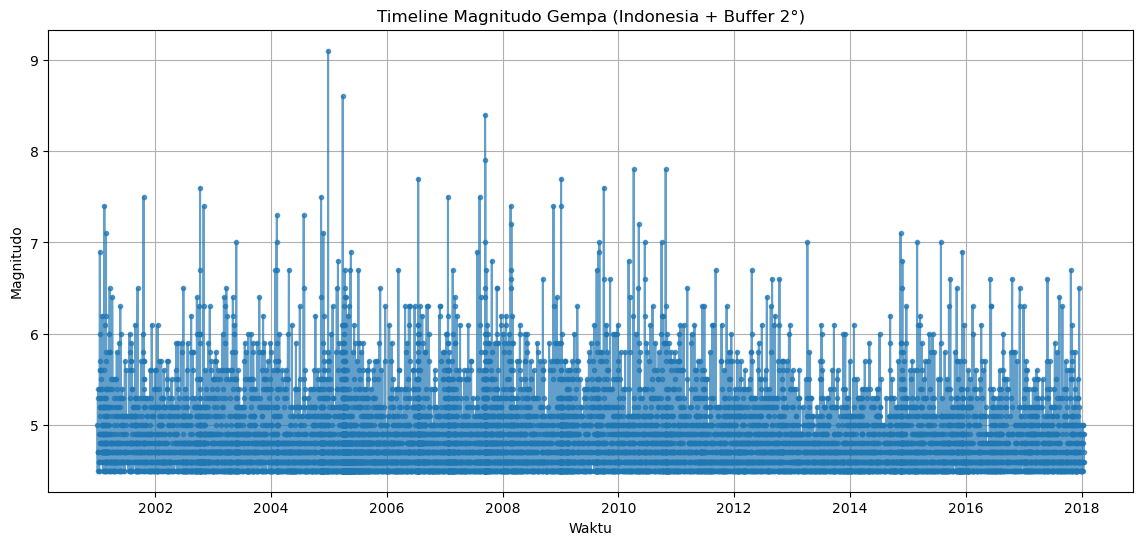

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Path data
path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv"

# Load data
df = pd.read_csv(path)

# Pastikan kolom waktu dalam format datetime
df['time'] = pd.to_datetime(df['time'])

# Sort berdasarkan waktu
df = df.sort_values('time')

# Plot timeline magnitudo
plt.figure(figsize=(14, 6))
plt.plot(df['time'], df['mag'], marker='o', markersize=3, linestyle='-', alpha=0.7)

plt.title("Timeline Magnitudo Gempa (Indonesia + Buffer 2°)")
plt.xlabel("Waktu")
plt.ylabel("Magnitudo")
plt.grid(True)

plt.show()


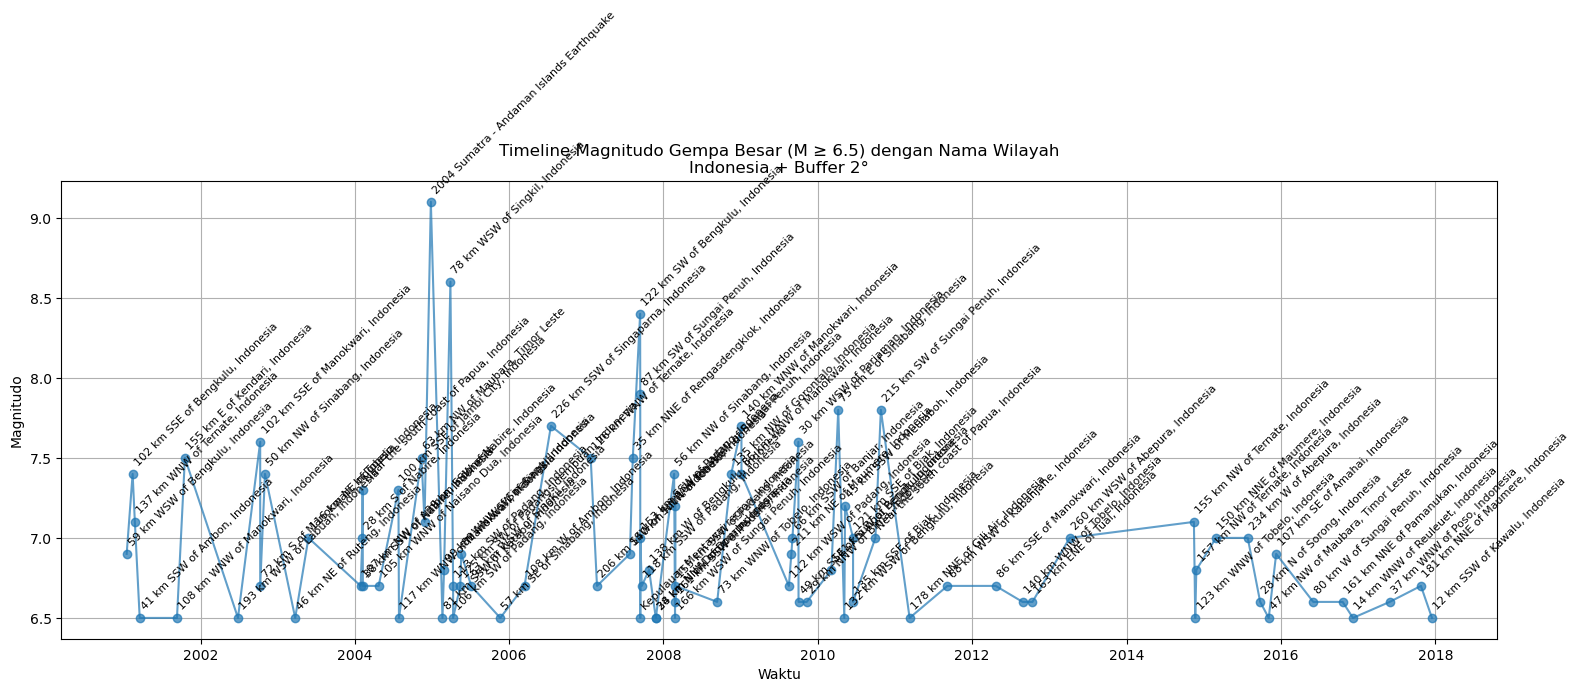

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Path data
path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv"

# Load data
df = pd.read_csv(path)

# Pastikan kolom waktu dalam format datetime
df['time'] = pd.to_datetime(df['time'])

# Filter gempa besar yang merusak (M ≥ 6.5)
big = df[df['mag'] >= 6.5].copy()

# Sort berdasarkan waktu
big = big.sort_values('time')

# Plot timeline magnitudo
plt.figure(figsize=(16, 7))
plt.plot(big['time'], big['mag'], marker='o', markersize=6, linestyle='-', alpha=0.7)

# Tambahkan label wilayah (kolom 'place')
for _, row in big.iterrows():
    label = row['place']
    plt.text(row['time'], row['mag'] + 0.05, label, fontsize=8, rotation=45)

plt.title("Timeline Magnitudo Gempa Besar (M ≥ 6.5) dengan Nama Wilayah\nIndonesia + Buffer 2°")
plt.xlabel("Waktu")
plt.ylabel("Magnitudo")
plt.grid(True)
plt.tight_layout()
plt.show()


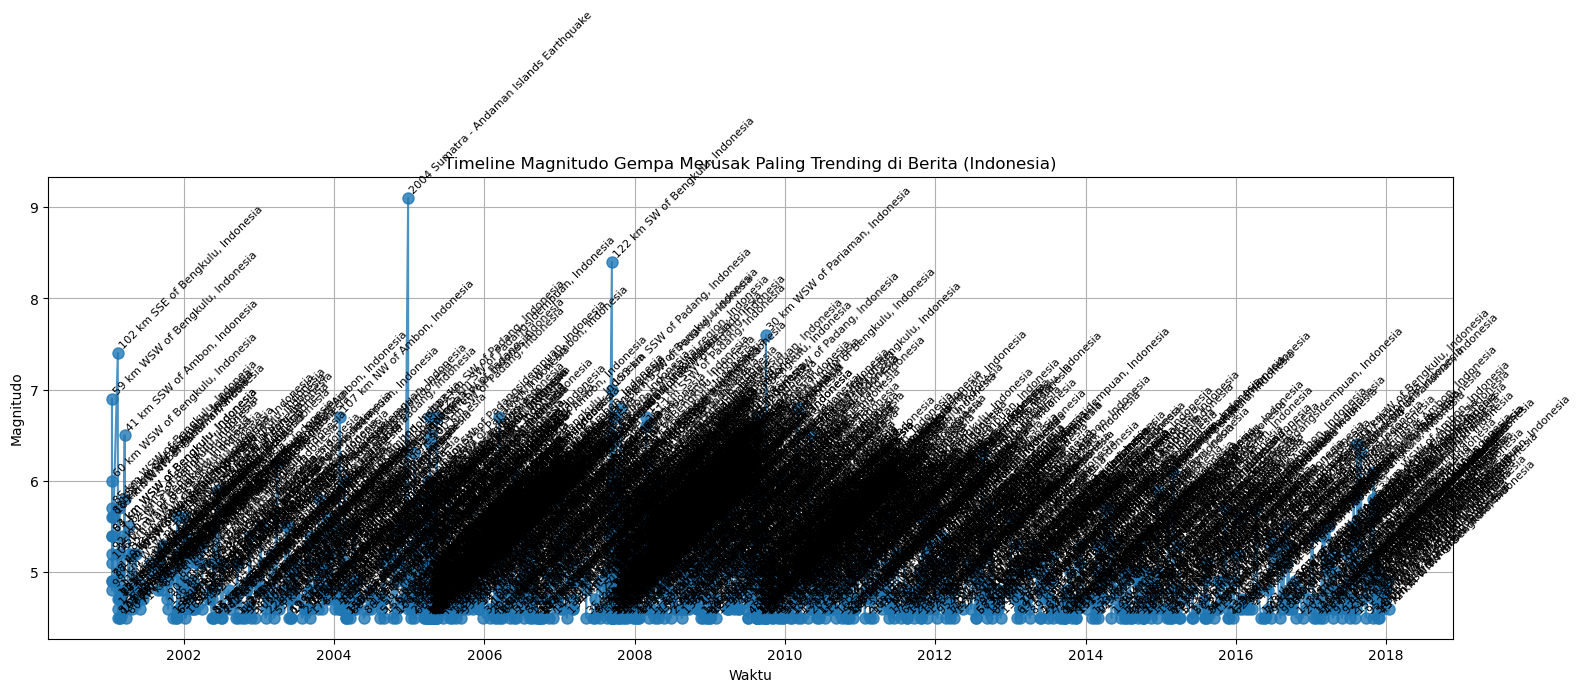

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Path data
path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv"

# Load data
df = pd.read_csv(path)
df['time'] = pd.to_datetime(df['time'])

# Daftar gempa trending (berdasarkan kata kunci wilayah)
keywords = [
    "Aceh", "Andaman", "Nias", "Bengkulu", "Mentawai",
    "Yogyakarta", "DIY", "Padang", "Pariaman",
    "Lombok", "Palu", "Donggala", "Ambon",
    "Majene", "Mamuju", "Cianjur"
]

# Filter berdasarkan kata kunci di kolom 'place'
mask = df['place'].str.contains('|'.join(keywords), case=False, na=False)
trending = df[mask].copy().sort_values('time')

# Plot timeline
plt.figure(figsize=(16, 7))
plt.plot(trending['time'], trending['mag'], marker='o', markersize=8, linestyle='-', alpha=0.8)

# Tambahkan label wilayah
for _, row in trending.iterrows():
    plt.text(row['time'], row['mag'] + 0.05, row['place'], fontsize=8, rotation=45)

plt.title("Timeline Magnitudo Gempa Merusak Paling Trending di Berita (Indonesia)")
plt.xlabel("Waktu")
plt.ylabel("Magnitudo")
plt.grid(True)
plt.tight_layout()
plt.show()


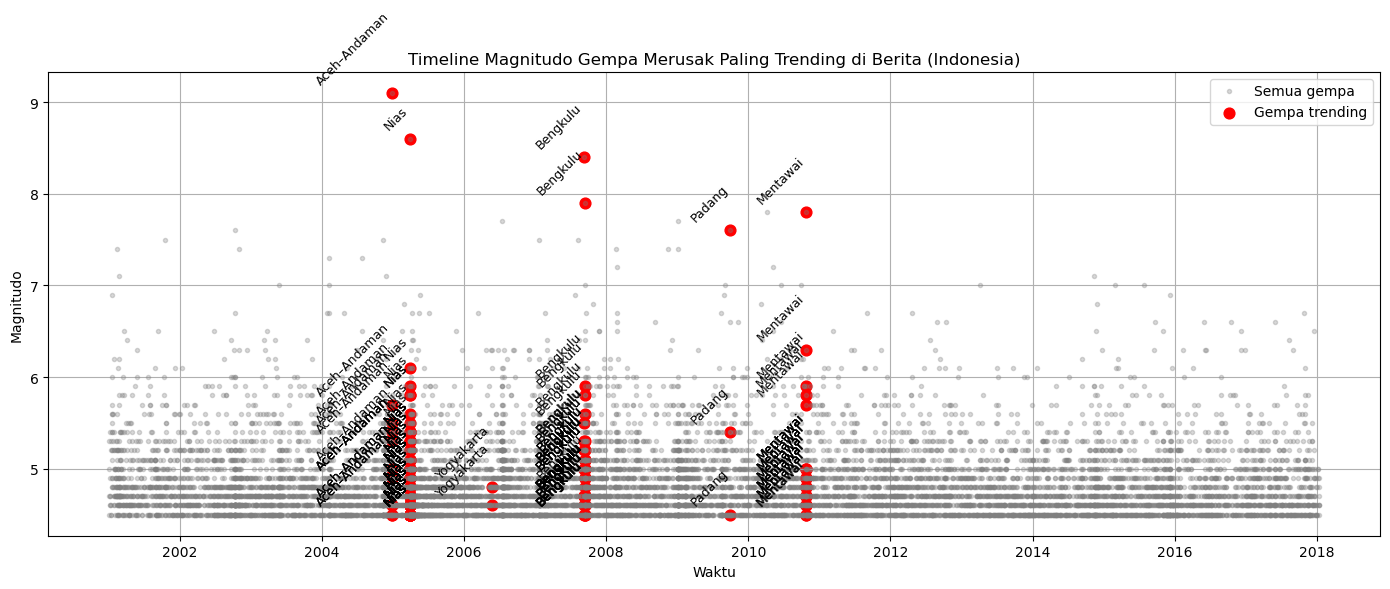

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Path data
path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv"

# Load data
df = pd.read_csv(path)
df['time'] = pd.to_datetime(df['time'])

# Daftar gempa trending di berita
trending_events = {
    "2004-12-26": "Aceh–Andaman",
    "2005-03-28": "Nias",
    "2006-05-27": "Yogyakarta",
    "2007-09-12": "Bengkulu",
    "2009-09-30": "Padang",
    "2010-10-25": "Mentawai",
    "2018-07-29": "Lombok",
    "2018-09-28": "Palu",
    "2019-09-26": "Ambon",
    "2021-01-15": "Mamuju",
    "2022-11-21": "Cianjur"
}

# Ambil event yang cocok dengan tanggal
df['date'] = df['time'].dt.date.astype(str)
trend_df = df[df['date'].isin(trending_events.keys())].copy()
trend_df['region'] = trend_df['date'].map(trending_events)

# Plot timeline
plt.figure(figsize=(14, 6))
plt.plot(df['time'], df['mag'], '.', color='gray', alpha=0.3, label='Semua gempa')
plt.scatter(trend_df['time'], trend_df['mag'], color='red', s=60, label='Gempa Merusak')

# Tambahkan label wilayah
for _, row in trend_df.iterrows():
    plt.text(row['time'], row['mag'] + 0.1, row['region'], fontsize=9, rotation=45, ha='right')

plt.title("Timeline Magnitudo Gempa Merusak (Indonesia)")
plt.xlabel("Waktu")
plt.ylabel("Magnitudo")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
